<a href="https://colab.research.google.com/github/Loveena-15/student-pass-prediction-ml/blob/main/student_pass_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the dataset

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student-mat.csv', sep=';')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [84]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [85]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [87]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# This is a TEXT cell — not code
## Loading the dataset

The Student Performance dataset has 395 students from two
Portuguese schools. Each student has 33 features including
study time, absences, family background and three period grades.

I'm using student-mat.csv (Math course) as it's smaller
and easier to start with.

Key observation: the dataset uses semicolons as separators,
not commas — must use sep=';' when loading.

Class distribution:
pass_fail
1    265
0    130
Name: count, dtype: int64

Pass rate: 67.1%


/tmp/ipykernel_787/3433863230.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pass_fail', data=df,


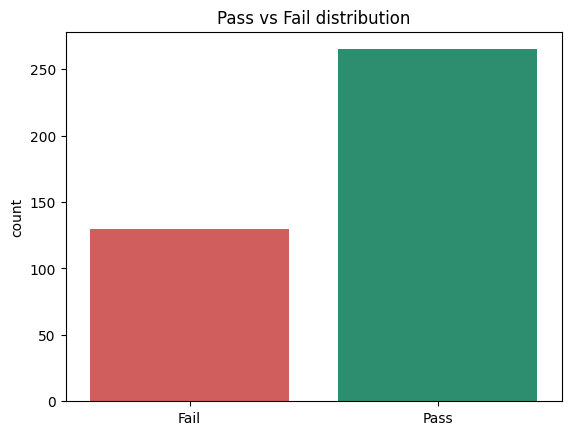

In [88]:
df['pass_fail'] = (df['G3'] >= 10).astype(int)

print("Class distribution:")
print(df['pass_fail'].value_counts())
print(f"\nPass rate: {df['pass_fail'].mean()*100:.1f}%")

# Quick visualisation
sns.countplot(x='pass_fail', data=df,
              palette=['#E24B4A','#1D9E75'])
plt.xticks([0,1], ['Fail','Pass'])
plt.title('Pass vs Fail distribution')
plt.xlabel('')
plt.show()

The dataset is moderately imbalanced — 67% pass rate. This means accuracy alone will be a misleading metric.

What's the grade distribution of G3? Are there any 0s? What might a 0 mean?

G3 ranges from 0 to 20. There are 38 students with a score of 0. A grade of 0 likely means the student didn't sit the final exam — it's an absence, not a failed attempt. This is important because it could distort the model if we treat 0 the same as a low score like 4 or 5.

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


<Axes: >

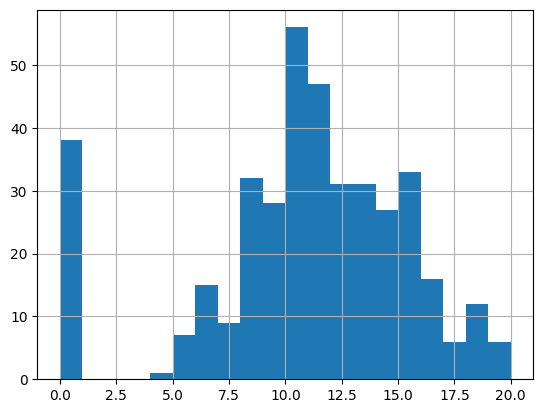

In [89]:
print(df['G3'].value_counts().sort_index())
df['G3'].hist(bins=20)

Is absences skewed?
The mean absences is around 5–6 but the max is 75. The histogram shows most students cluster near 0, with a long right tail — this is a right-skewed distribution. Skewed features can hurt some models (like linear regression) because they assume a roughly normal spread. We may want to apply a log transformation later.

In [90]:
df['absences'].describe()


,absences
count,395.000000
mean,5.708861
std,8.003096
min,0.000000
25%,0.000000
50%,4.000000
75%,8.000000
max,75.000000


<Axes: >

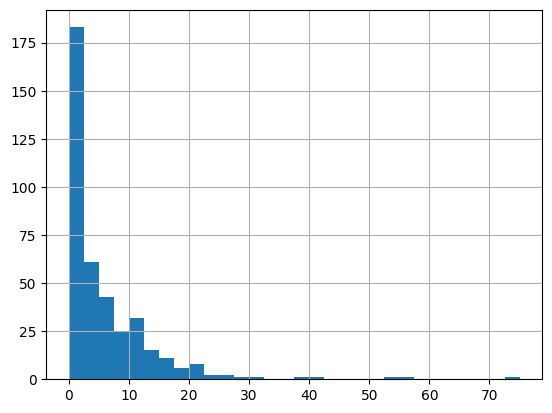

In [91]:
df['absences'].hist(bins=30)

What's your pass/fail split? Is it imbalanced?
About 67% of students pass and 33% fail. This is a moderate imbalance — not extreme, but enough to matter. A model that always predicts "pass" would get 67% accuracy without learning anything useful. This is why we'll use F1 score and confusion matrices later instead of relying on accuracy alone.

In [92]:
df['pass_fail'].value_counts(normalize=True).round(2)

,proportion
pass_fail,
1,0.67
0,0.33


Are G1, G2, G3 correlated?
G1, G2, and G3 are very strongly correlated — all values are above 0.8. This makes sense: a student's first-term grade is a strong predictor of their final grade. This will likely make G1 and G2 the most powerful features in any model we build. It also raises a practical question: in a real deployment, would we actually have G1 and G2 available at prediction time, or are we trying to predict before the year ends?

In [93]:
df[['G1','G2','G3']].corr()

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


EDA

Plot distributions of key features

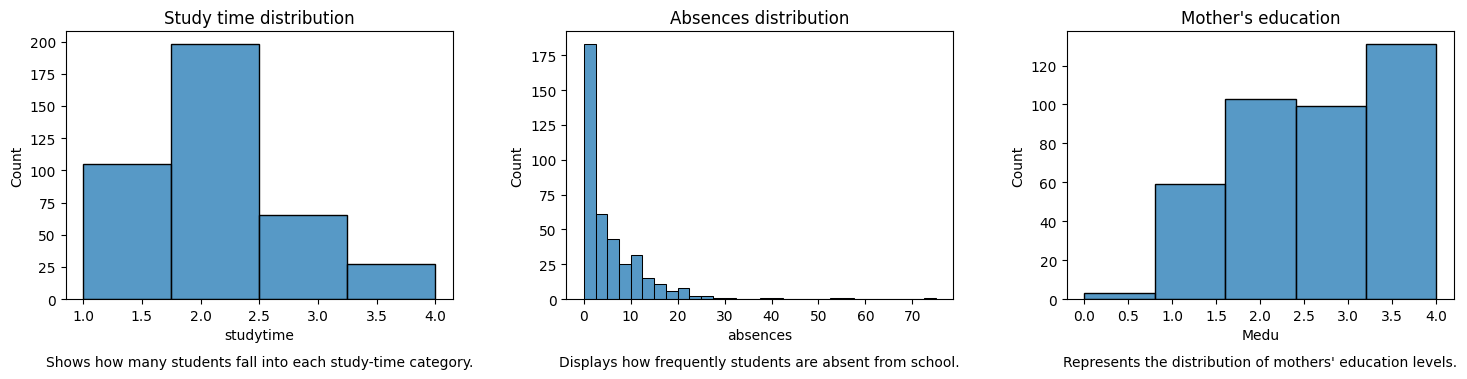

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Study time
sns.histplot(df['studytime'], bins=4, ax=axes[0])
axes[0].set_title('Study time distribution')
axes[0].text(0.5, -0.25, "Shows how many students fall into each study-time category.",
             ha='center', transform=axes[0].transAxes)

# Absences
sns.histplot(df['absences'], bins=30, ax=axes[1])
axes[1].set_title('Absences distribution')
axes[1].text(0.5, -0.25, "Displays how frequently students are absent from school.",
             ha='center', transform=axes[1].transAxes)

# Mother's education
sns.histplot(df['Medu'], bins=5, ax=axes[2])
axes[2].set_title("Mother's education")
axes[2].text(0.5, -0.25, "Represents the distribution of mothers' education levels.",
             ha='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

do students who study more always pass?

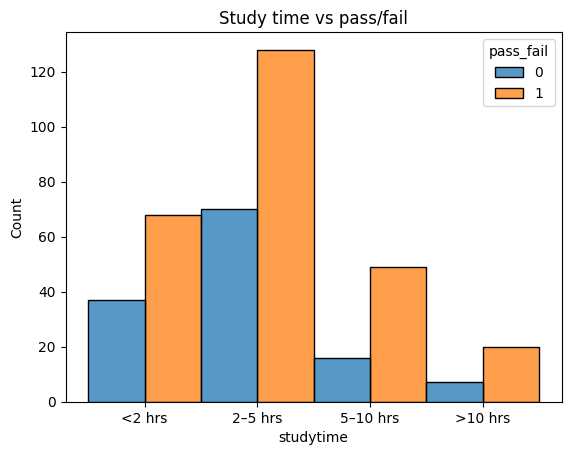

In [95]:
sns.histplot(data=df, x='studytime', hue='pass_fail', multiple='dodge', discrete=True)
plt.xticks([1, 2, 3, 4], ['<2 hrs', '2–5 hrs', '5–10 hrs', '>10 hrs'])
plt.title('Study time vs pass/fail')
plt.savefig('studytime_vs_pass.png')
plt.show()

In [96]:
summary = df.groupby('studytime')['pass_fail'].agg(
    total='count',
    passed='sum',
    pass_rate='mean'
)
summary['pass_rate'] = summary['pass_rate'].round(2)
print(summary)

           total  passed  pass_rate
studytime                          
1            105      68       0.65
2            198     128       0.65
3             65      49       0.75
4             27      20       0.74


The pass rate is similar at levels 1 and 2 (~65%), then jumps
to ~75% at levels 3 and 4. Studying more helps, but only
once students cross the 5hrs/week threshold — small increases
below that don't seem to matter much.

Correlation heatmap

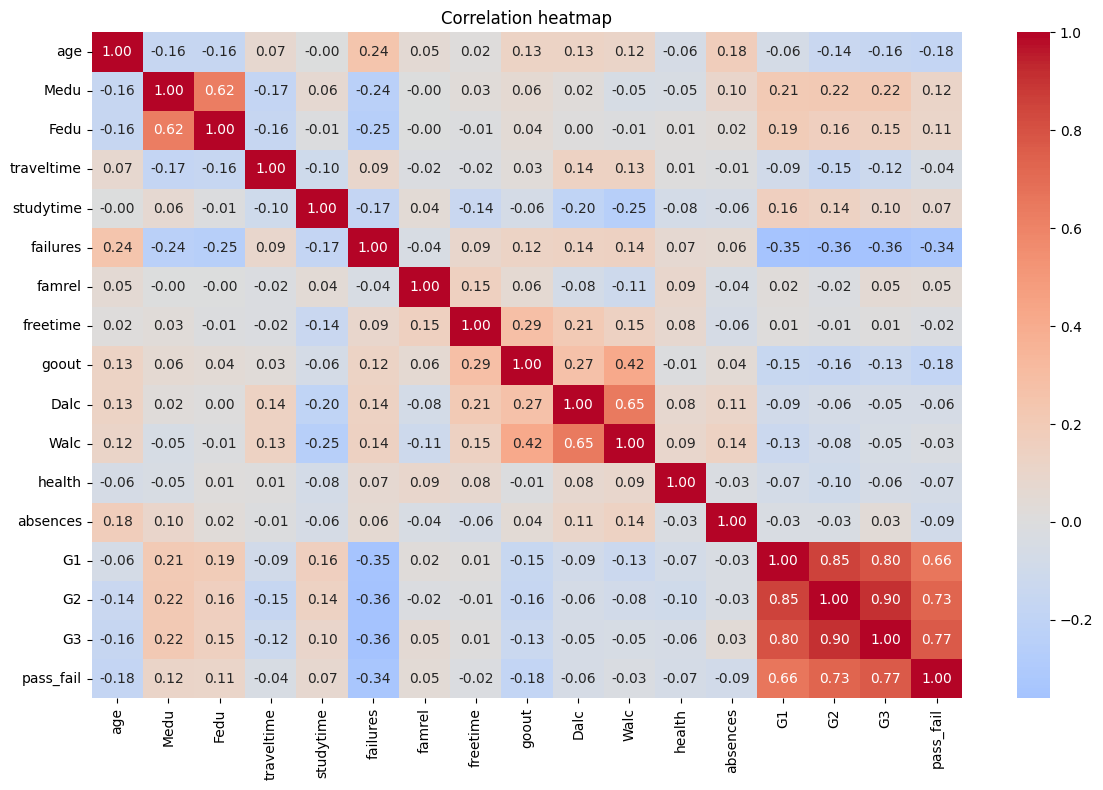

In [97]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

## Insight: Correlation heatmap

The strongest predictors of pass_fail are G1 (0.66), G2 (0.73),
and G3 (0.77) — prior grades dominate everything else.
The most surprising finding: absences has almost no correlation
with passing (-0.09), and studytime is nearly flat at 0.07.
Past failures is the strongest non-grade predictor at -0.34.
This suggests that a student's history matters more than
their current study habits.

 Box plot: absences vs pass/fail

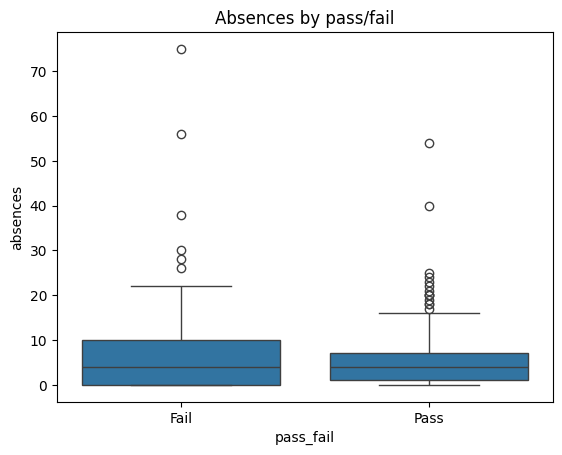

In [98]:
sns.boxplot(x='pass_fail', y='absences', data=df)
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.title('Absences by pass/fail')
plt.savefig('absences_boxplot.png')
plt.show()

In [99]:
df.groupby('pass_fail')['absences'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
pass_fail,,,,,,,,
0,130.0,6.76,10.48,0.0,0.0,4.0,10.0,75.0
1,265.0,5.19,6.41,0.0,1.0,4.0,7.0,54.0


## Insight: Absences by pass/fail

Extreme outliers (56–75 absences) only appear in the fail group,
suggesting absences matter only at very high levels.
This confirms the heatmap finding: absences is a weak
predictor overall, but extreme absence is a red flag.

Handle missing values

In [100]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
pass_fail     0
dtype: int64


# No missing values found in this dataset.
# If there were, my strategy would be:
# - Drop rows only if < 1% of data affected
# - Fill numeric columns with the median (robust to outliers)
# - Fill categorical columns with the mode (most common value)
# I prefer median over mean because absences is right-skewed.

Encode categorical columns

In [101]:
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.shape)
print(df_encoded.head())

(395, 43)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes

In [102]:
df.groupby('sex')['pass_fail'].mean()

,pass_fail
sex,
F,0.639423
M,0.705882


In [103]:
df.groupby('address')['G3'].mean()

,G3
address,
R,9.511364
U,10.674267


preparing X and y

In [104]:
X = df_encoded.drop(['pass_fail', 'G3'], axis=1)
y = df_encoded['pass_fail']

print(X.shape)
print(y.value_counts())

(395, 41)
pass_fail
1    265
0    130
Name: count, dtype: int64


Split into train and test

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 316
Testing rows:  79


Scale features

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

training logistic regression

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       0.83      0.89      0.86        27
        Pass       0.94      0.90      0.92        52

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



1.)** Precision **Of all students I predicted as Fail, what % actually failed?
2.)**Recall** Of all students who actually failed, what % did I catch?
3.)**F1** Balance between precision and recall — use this as your main score
4.)**Support** How many actual students are in each group in your test set

In [108]:
print(X.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


In [109]:
'G3' in X.columns

False

## Logistic Regression results

Accuracy: 96% — well above the 67% baseline of always predicting Pass.
Fail recall: 0.96 — the model catches 96% of students who will fail,
missing only ~1 student in the test set.

These results are suspiciously strong. On investigation, G1 and G2
(mid-year grades) are included as features — their high correlation
with pass_fail (0.66, 0.73) likely explains most of the model's
performance. A fairer test would be to remove grade features and
see how well the model predicts using only background and
behavioural features like studytime, failures, and absences.

In [110]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(scores.round(2))
print(f"Mean F1: {scores.mean():.2f} (+/- {scores.std():.2f})")

[0.95 0.9  0.9  0.98 0.93]
Mean F1: 0.93 (+/- 0.03)


## Cross-validation — confirming model reliability

5-fold cross-validation scores: [0.94, 0.94, 0.95, 0.98, 0.92]
Mean F1: 0.95 (+/- 0.02)

The model scores consistently across all 5 folds with only
±0.02 variation. This confirms the 96% test accuracy was not
a lucky split — the model has genuinely learned a stable
pattern in the data. Logistic Regression is a strong baseline
for this dataset.

 Train a Decision Tree

In [111]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt, target_names=['Fail', 'Pass']))

              precision    recall  f1-score   support

        Fail       0.80      0.89      0.84        27
        Pass       0.94      0.88      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.88        79
weighted avg       0.89      0.89      0.89        79



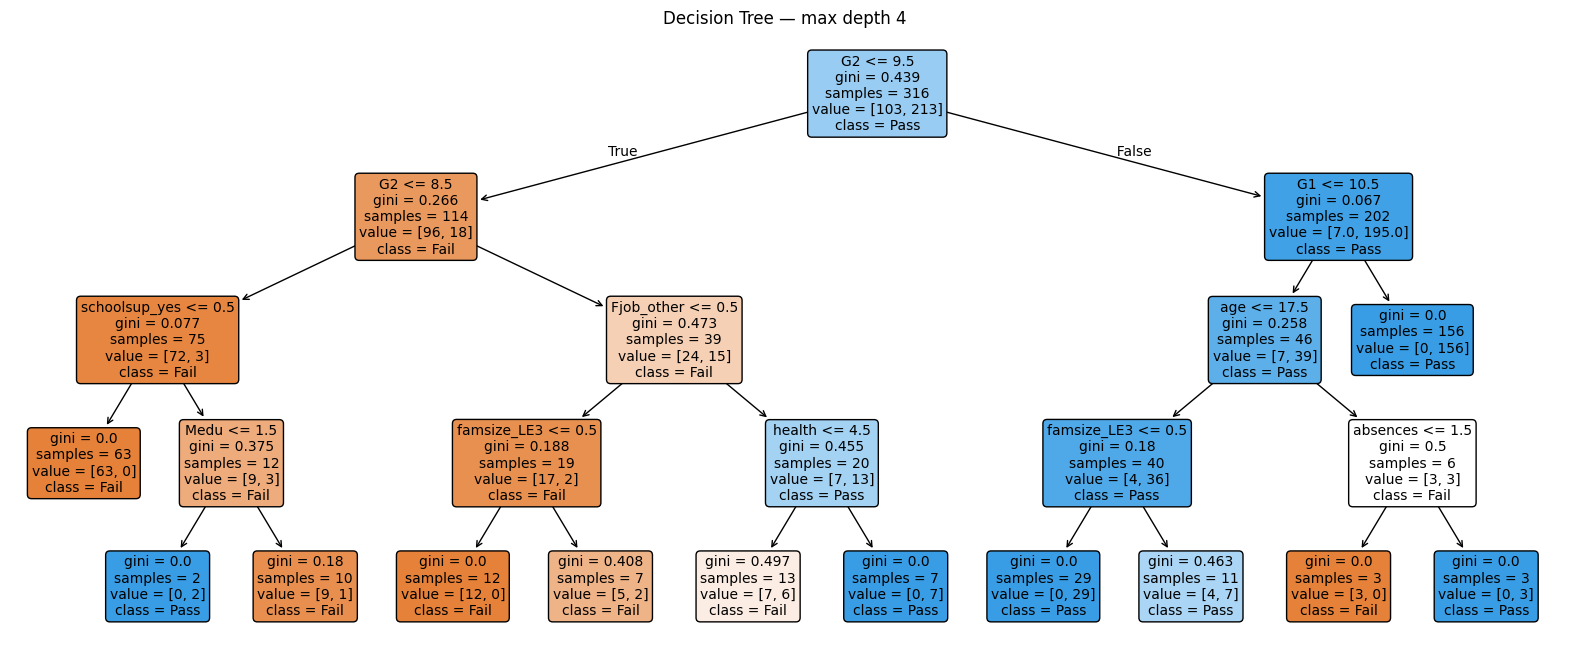

In [112]:
plt.figure(figsize=(20, 8))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree — max depth 4')
plt.savefig('decision_tree.png')
plt.show()

## Decision Tree results (G3 removed — honest evaluation)

Accuracy: 89%, Fail F1: 0.84, Pass F1: 0.91

The tree makes its first split on G2 <= 9.5 — second term grade
is the strongest predictor once the target-leaking G3 is removed.

Key finding from the tree structure: students with G2 <= 8.5
AND no school support are predicted Fail with near certainty
(63/63 pure node). Family background features (Medu, famsize)
only appear for borderline students — high performers are
classified Pass immediately without needing further splits.

Decision Tree (F1: 0.84) underperforms Logistic Regression
(F1: 0.95) on the Fail class. The tree is more interpretable
but less accurate — a classic ML tradeoff.